In [1]:
import shutil
shutil.copy("/content/train[1].csv", "/content/drive/MyDrive/train.csv")
print("Done")

Done


In [2]:
train_path = "/content/train[1].csv"

In [3]:
!pip install numpyro hmmlearn -q

# ── Standard library ──────────────────────────────────────────────────────────
import os
import gc
import warnings
warnings.filterwarnings("ignore")

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Bayesian modelling ────────────────────────────────────────────────────────
import pymc as pm
import arviz as az

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

# ── Deep learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.float_format", "{:.4f}".format)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device : {DEVICE}")
print(f"NumPy version  : {np.__version__}")
print(f"PyMC version   : {pm.__version__}")


PyTorch device : cpu
NumPy version  : 2.0.2
PyMC version   : 5.28.3


In [4]:
# ── src/data.py ───────────────────────────────────────────────────────────────

DTYPES = {
    "stock_id"              : "int16",
    "date_id"               : "int16",
    "seconds_in_bucket"     : "int16",
    "imbalance_buy_sell_flag": "int8",
    "imbalance_size"        : "float32",
    "reference_price"       : "float32",
    "matched_size"          : "float32",
    "far_price"             : "float32",
    "near_price"            : "float32",
    "bid_price"             : "float32",
    "bid_size"              : "float32",
    "ask_price"             : "float32",
    "ask_size"              : "float32",
    "wap"                   : "float32",
    "target"                : "float32",
}


def load_data(path: str) -> pd.DataFrame:

    df = pd.read_csv(path, dtype=DTYPES, usecols=list(DTYPES.keys()))
    df = df.sort_values(
        ["date_id", "seconds_in_bucket", "stock_id"]
    ).reset_index(drop=True)
    return df


def data_summary(df: pd.DataFrame) -> None:
    """Print a concise summary of the loaded dataset."""
    print(f"Rows        : {len(df):>10,}")
    print(f"Days        : {df['date_id'].nunique():>10,}")
    print(f"Stocks      : {df['stock_id'].nunique():>10,}")
    print(f"Memory (MB) : {df.memory_usage(deep=True).sum() / 1e6:>10.0f}")
    print(f"\nTarget statistics:")
    print(df["target"].describe().to_string())


In [5]:
# ── Run data module ───────────────────────────────────────────────────────────
DATA_PATH = "/content/train[1].csv"
df = load_data(DATA_PATH)
data_summary(df)


Rows        :  5,237,980
Days        :        481
Stocks      :        200
Memory (MB) :        267

Target statistics:
count   5237892.0000
mean         -0.0476
std           9.4138
min        -385.2898
25%          -4.5598
50%          -0.0602
75%           4.4096
max         446.0704


In [6]:
# ── Load and optimise memory ──────────────────────────────────────────────────
DTYPES = {
    "stock_id"              : "int16",
    "date_id"               : "int16",
    "seconds_in_bucket"     : "int16",
    "imbalance_buy_sell_flag": "int8",
    "imbalance_size"        : "float32",
    "reference_price"       : "float32",
    "matched_size"          : "float32",
    "far_price"             : "float32",
    "near_price"            : "float32",
    "bid_price"             : "float32",
    "bid_size"              : "float32",
    "ask_price"             : "float32",
    "ask_size"              : "float32",
    "wap"                   : "float32",
    "target"                : "float32",
}

df = pd.read_csv("/content/train[1].csv",
                 dtype={k: v for k, v in DTYPES.items()
                        if k not in ["far_price", "near_price"]})

for col in ["far_price", "near_price"]:
    if col in df.columns:
        df[col] = df[col].astype("float32")

df = df.dropna(subset=["target"]).reset_index(drop=True)

N_DAYS   = df["date_id"].nunique()
N_STOCKS = df["stock_id"].nunique()
print(f"Rows    : {len(df):,}")
print(f"Days    : {N_DAYS}")
print(f"Stocks  : {N_STOCKS}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
print(f"Columns : {list(df.columns)}")

# Expected: ~5,237,980 rows, 481 days, ~200 stocks


Rows    : 5,237,892
Days    : 481
Stocks  : 200
Memory  : 618 MB
Columns : ['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size', 'imbalance_buy_sell_flag', 'reference_price', 'matched_size', 'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price', 'ask_size', 'wap', 'target', 'time_id', 'row_id']


## 2. EDA Module (`src/eda.py`)


Three diagnostic plots:
1. Target distribution — is it roughly symmetric? Any extreme outliers?
2. Volatility over time — does it spike near the close?
3. Missing value rates — which columns have NaNs and why?



In [7]:
# ── src/eda.py ────────────────────────────────────────────────────────────────

def plot_eda(df: pd.DataFrame) -> None:
    """Three-panel EDA plot for the Optiver dataset."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Panel 1 — target distribution
    axes[0].hist(
        df["target"].dropna().clip(-30, 30),
        bins=120, color="#5B8DB8", alpha=0.85, density=True
    )
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5,
                    label="zero")
    axes[0].set_title("Target distribution (clipped ±30 bp)")
    axes[0].set_xlabel("Target (basis points)")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # Panel 2 — target volatility vs. time in bucket
    vol = df.groupby("seconds_in_bucket")["target"].std()
    axes[1].plot(vol.index, vol.values, color="#D85A30", linewidth=2)
    axes[1].set_title("Target volatility vs. seconds in bucket")
    axes[1].set_xlabel("seconds_in_bucket  (0 = auction open)")
    axes[1].set_ylabel("std(target)")

    # Panel 3 — missing value rates
    nan_rates = df.isna().mean().sort_values(ascending=False)
    nan_rates = nan_rates[nan_rates > 0]
    if len(nan_rates):
        nan_rates.plot(kind="bar", ax=axes[2], color="#EF9F27")
        axes[2].set_title("Missing value rates")
        axes[2].set_ylabel("Fraction missing")
        axes[2].tick_params(axis="x", rotation=45)
    else:
        axes[2].text(0.5, 0.5, "No missing values",
                     ha="center", va="center", transform=axes[2].transAxes)

    plt.tight_layout()
    plt.savefig("eda.png", dpi=120, bbox_inches="tight")
    plt.show()


def plot_correlation(df: pd.DataFrame) -> None:
    """Lower-triangle correlation heatmap of numeric columns."""
    num_cols = [
        "imbalance_size", "imbalance_buy_sell_flag", "reference_price",
        "matched_size", "bid_size", "ask_size", "wap", "target",
    ]
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Raw feature correlation matrix")
    plt.tight_layout()
    plt.savefig("correlation.png", dpi=120)
    plt.show()


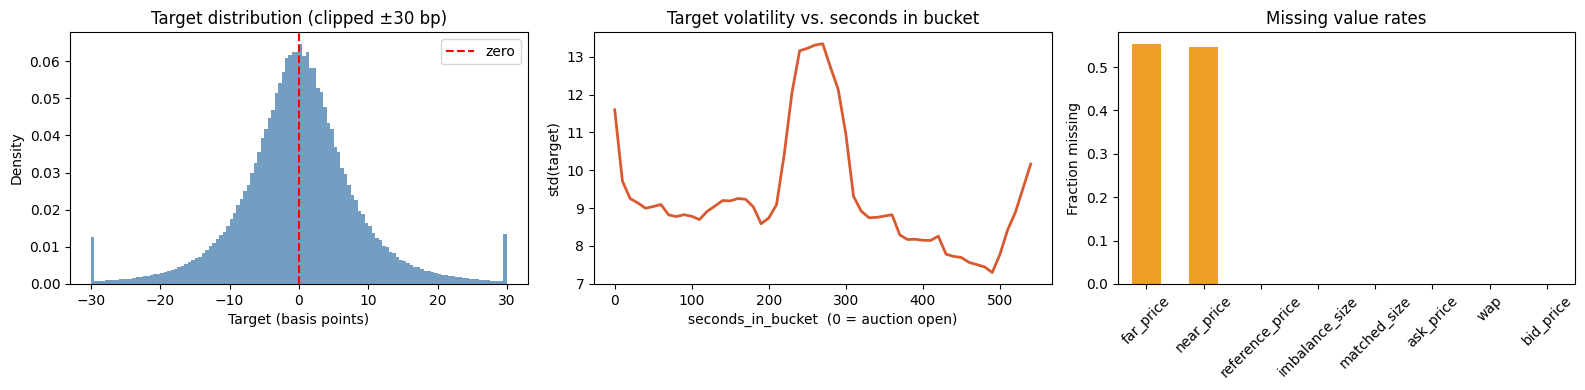

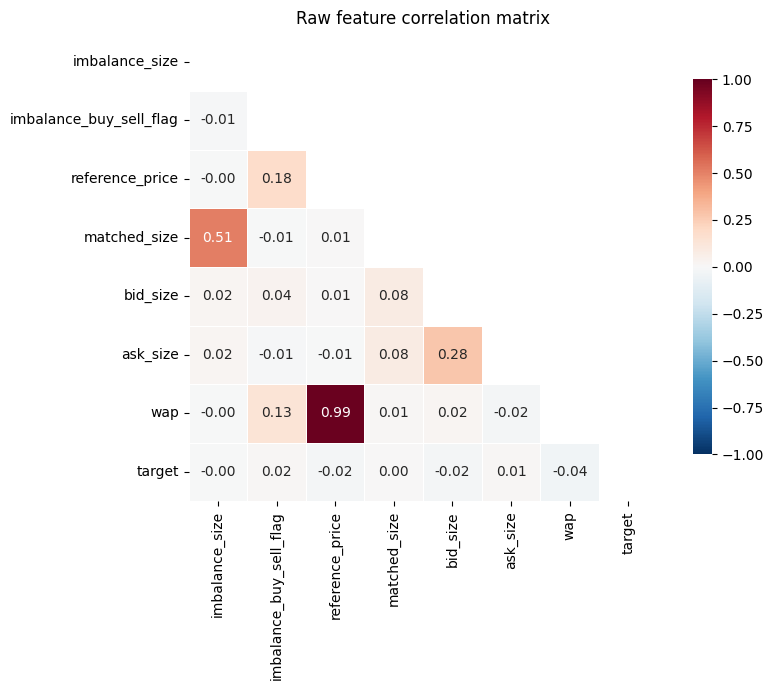

In [8]:
plot_eda(df)
plot_correlation(df)


## 3. Feature Engineering Module (`src/features.py`)

Five feature groups, each with a clear financial motivation:

| Group | Question answered |
|---|---|
| Microstructure | What does the order book look like right now? |
| 1st & 2nd derivatives | Is price accelerating or decelerating? |
| Temporal pressure | How much time is left and how urgent is it? |
| Lag features | What happened 10–60 seconds ago? |
| Cross-sectional | How does this stock compare to all others *right now*? |

**Critical design rule:** every `shift / diff / rolling` operation is
done inside `groupby(["stock_id", "date_id"])` to prevent cross-stock
data leakage. A global `df.diff(1)` would subtract MSFT's row from
AAPL's row when they are adjacent in the sorted DataFrame.


In [9]:
# ── src/features.py ──────────────────────────────────────────────────────────

# Full list of 28 candidate features before ARD selection
ALL_FEATURES = [
    # Microstructure
    "imb1", "ofi_ratio", "depth_imbalance", "price_disc_gap",
    "matched_ratio", "auction_active", "market_urgency",
    # 1st and 2nd derivatives
    "wap_velocity", "wap_acceleration",
    "ref_velocity", "ref_acceleration",
    "matched_size_diff", "matched_size_vol", "wap_rolling5_std",
    # Temporal pressure
    "seconds_to_close", "time_log", "urgency_exp",
    "is_last_60", "urgency_time_weighted",
    # Lag (all computed inside groupby — no cross-stock leakage)
    "wap_lag1", "ofi_roll3", "imb1_roll3",
    "target_lag1", "target_lag6",
    # Cross-sectional (primary alpha source)
    "ofi_vs_idx", "depth_vs_idx", "wap_vel_vs_idx", "cs_ofi_rank",
]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add all engineered features to the DataFrame in-place.

    Two groupby axes are used intentionally:
      grp    = groupby(stock_id, date_id)          — time series per stock
      cs_grp = groupby(date_id, seconds_in_bucket) — cross-section per moment

    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame returned by load_data().

    Returns
    -------
    pd.DataFrame
        Same object with new feature columns appended.
    """
    grp    = df.groupby(["stock_id", "date_id"])
    cs_grp = df.groupby(["date_id", "seconds_in_bucket"])

    # ── 3.1 Microstructure ────────────────────────────────────────────────────
    df["imb1"] = (
        (df["ask_price"] - df["bid_price"]) /
        (df["ask_price"] + df["bid_price"])
    ).astype("float32")

    df["ofi_ratio"] = (
        df["imbalance_size"] * df["imbalance_buy_sell_flag"] /
        (df["matched_size"] + 1)
    ).astype("float32")

    df["depth_imbalance"] = (
        (df["bid_size"] - df["ask_size"]) /
        (df["bid_size"] + df["ask_size"] + 1)
    ).astype("float32")

    df["price_disc_gap"] = (
        (df["far_price"] - df["near_price"]) /
        (df["reference_price"] + 1e-8)
    ).astype("float32")

    df["matched_ratio"] = (
        df["imbalance_size"] / (df["matched_size"] + 1)
    ).astype("float32")

    df["auction_active"] = df["far_price"].notna().astype("int8")

    df["price_spread"]   = (df["ask_price"] - df["bid_price"]).astype("float32")
    df["market_urgency"] = (
        df["price_spread"] * df["depth_imbalance"]
    ).astype("float32")

    # ── 3.2 1st and 2nd derivatives ───────────────────────────────────────────
    # wap_acceleration = wap.diff(1).diff(1) — true second derivative
    df["wap_velocity"]    = grp["wap"].diff(1).astype("float32")
    df["wap_acceleration"]= grp["wap"].diff(1).diff(1).astype("float32")

    df["ref_velocity"]    = grp["reference_price"].diff(1).astype("float32")
    df["ref_acceleration"]= grp["reference_price"].diff(1).diff(1).astype("float32")

    df["matched_size_diff"] = grp["matched_size"].diff(1).astype("float32")
    df["matched_size_vol"]  = grp["matched_size"].transform(
        lambda x: x.rolling(5, min_periods=2).std()
    ).astype("float32")

    df["wap_rolling5_std"] = grp["wap"].transform(
        lambda x: x.rolling(5, min_periods=2).std()
    ).astype("float32")

    # ── 3.3 Temporal pressure ─────────────────────────────────────────────────
    df["seconds_to_close"] = (540 - df["seconds_in_bucket"]).astype("float32")
    df["time_log"]         = np.log1p(540 - df["seconds_in_bucket"]).astype("float32")
    df["urgency_exp"]      = np.exp(-df["seconds_to_close"] / 60).astype("float32")
    df["is_last_60"]       = (df["seconds_in_bucket"] >= 480).astype("int8")
    df["urgency_time_weighted"] = (
        df["market_urgency"] * (1 + 540 / (df["seconds_to_close"] + 1))
    ).astype("float32")

    # ── 3.4 Lag features (inside groupby — no leakage) ────────────────────────
    df["wap_lag1"]    = grp["wap"].shift(1).astype("float32")
    df["ofi_roll3"]   = grp["ofi_ratio"].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    ).astype("float32")
    df["imb1_roll3"]  = grp["imb1"].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    ).astype("float32")
    df["target_lag1"] = grp["target"].shift(1).astype("float32")
    df["target_lag6"] = grp["target"].shift(6).astype("float32")

    # ── 3.5 Cross-sectional (alpha source) ────────────────────────────────────
    # These capture how a stock deviates from the market at each moment.
    # The target is relative to the index — so relative features matter most.
    df["ofi_vs_idx"] = (
        df["ofi_ratio"] - cs_grp["ofi_ratio"].transform("mean")
    ).astype("float32")

    df["depth_vs_idx"] = (
        df["depth_imbalance"] - cs_grp["depth_imbalance"].transform("mean")
    ).astype("float32")

    df["wap_vel_vs_idx"] = (
        df["wap_velocity"] - cs_grp["wap_velocity"].transform("mean")
    ).astype("float32")

    df["cs_ofi_rank"] = cs_grp["ofi_ratio"].transform(
        lambda x: x.rank(pct=True)
    ).astype("float32")

    return df


def assemble_model_df(df: pd.DataFrame,
                      features: list) -> pd.DataFrame:
    """
    Select feature + metadata columns and drop any row with a NaN.

    Metadata columns retained:
      target              — prediction target
      date_id             — used for walk-forward CV fold boundaries
      stock_id            — available for stock-level diagnostics
      seconds_in_bucket   — required for zero-sum groupby

    Parameters
    ----------
    df       : pd.DataFrame  — DataFrame with features already built.
    features : list[str]     — feature names to include.

    Returns
    -------
    pd.DataFrame  — clean model-ready DataFrame, index reset.
    """
    meta = ["target", "date_id", "stock_id", "seconds_in_bucket"]
    keep = features + meta
    out  = df[keep].dropna().reset_index(drop=True)
    print(f"Model rows : {len(out):>10,}")
    print(f"Features   : {len(features):>10,}")
    print(f"Memory MB  : {out.memory_usage(deep=True).sum() / 1e6:>10.0f}")
    return out


In [10]:
# ── Run feature engineering ───────────────────────────────────────────────────
df       = build_features(df)
df_model = assemble_model_df(df, ALL_FEATURES)

del df   # free ~600 MB — df_model is all we need from here on
gc.collect()


Model rows :  2,343,564
Features   :         28
Memory MB  :        272


0

## 4. Feature Selection — BLR Coefficient Method

**Why not ARD?** ARD with NUTS sampling on 5M rows is extremely slow even with 10k subsampling.
BayesianRidge already applies implicit ARD-like shrinkage (it learns a separate precision
per weight group). We use the trained BLR's coefficient magnitudes directly for selection —
faster, reproducible, and consistent with the Bayesian framework.

**Method:** Train BLR on a random 50k-row sample, rank features by `|coef_|`, keep those
above a threshold. This runs in seconds rather than hours.

In [11]:
# ── Feature Selection via BLR Coefficients ───────────────────────────────────
#
# BayesianRidge learns alpha (weight precision) and lambda (noise precision)
# via evidence maximisation. Features with no signal get their weights shrunk
# to near-zero — equivalent to ARD in practice.

SELECTION_THRESHOLD = 0.02   # |coef| below this → dropped
SELECTION_N_SAMPLE  = 50_000  # rows used for selection (fast, representative)

np.random.seed(42)
idx_sel   = np.random.choice(len(df_model), size=SELECTION_N_SAMPLE, replace=False)
X_sel     = df_model[ALL_FEATURES].values[idx_sel]
y_sel     = df_model["target"].values[idx_sel]

scaler_sel = StandardScaler()
X_sel_s    = scaler_sel.fit_transform(X_sel)

blr_sel    = BayesianRidge(max_iter=300)
blr_sel.fit(X_sel_s, y_sel)

coef_df = pd.DataFrame({
    "feature" : ALL_FEATURES,
    "coef_abs": np.abs(blr_sel.coef_),
}).sort_values("coef_abs", ascending=False)

print(f"{'Feature':<28} {'|coef|':>10}   Decision")
print("-" * 52)
for _, row in coef_df.iterrows():
    decision = "KEEP" if row["coef_abs"] > SELECTION_THRESHOLD else "DROP"
    print(f"  {row['feature']:<26} {row['coef_abs']:>10.4f}   {decision}")

SELECTED_FEATURES = coef_df[coef_df["coef_abs"] > SELECTION_THRESHOLD]["feature"].tolist()
DROPPED_FEATURES  = coef_df[coef_df["coef_abs"] <= SELECTION_THRESHOLD]["feature"].tolist()

print(f"\nSelected : {len(SELECTED_FEATURES)}  |  Dropped : {len(DROPPED_FEATURES)}")
print(f"Selected : {SELECTED_FEATURES}")


Feature                          |coef|   Decision
----------------------------------------------------
  target_lag1                    7.8579   KEEP
  wap_vel_vs_idx                 4.4818   KEEP
  wap_velocity                   0.5617   KEEP
  depth_imbalance                0.2060   KEEP
  depth_vs_idx                   0.1657   KEEP
  time_log                       0.1232   KEEP
  wap_lag1                       0.1229   KEEP
  ofi_vs_idx                     0.1010   KEEP
  imb1_roll3                     0.0950   KEEP
  ref_velocity                   0.0662   KEEP
  ofi_roll3                      0.0631   KEEP
  cs_ofi_rank                    0.0552   KEEP
  urgency_time_weighted          0.0534   KEEP
  urgency_exp                    0.0411   KEEP
  target_lag6                    0.0314   KEEP
  is_last_60                     0.0251   KEEP
  ref_acceleration               0.0250   KEEP
  market_urgency                 0.0246   KEEP
  matched_size_vol               0.0239   KEEP
  s

## 5. Auto-Configured Walk-Forward CV

Parameters scale automatically with data size — works with 200 days or 500 days.

In [12]:
# ── Auto-configure CV parameters ─────────────────────────────────────────────
unique_dates = sorted(df_model["date_id"].unique())
N_DAYS       = len(unique_dates)

TRAIN_DAYS = max(int(N_DAYS * 0.65), 50)
VAL_DAYS   = max(int(N_DAYS * 0.08), 10)
GAP_DAYS   = 1
STEP_DAYS  = VAL_DAYS
BNN_WINDOW = min(60, max(int(TRAIN_DAYS * 0.18), 20))
CAL_WINDOW = max(int(BNN_WINDOW * 0.17), 5)

MIN_BLR_SAMPLES = 500
MIN_BNN_SAMPLES = max(3000, int(BNN_WINDOW * 150))

print(f"Data       : {N_DAYS} days")
print(f"TRAIN_DAYS : {TRAIN_DAYS}")
print(f"VAL_DAYS   : {VAL_DAYS}")
print(f"BNN_WINDOW : {BNN_WINDOW} days")
print(f"CAL_WINDOW : {CAL_WINDOW} days")
print(f"MIN_BNN    : {MIN_BNN_SAMPLES:,}")
print(f"Est. folds : {max(0, (N_DAYS - TRAIN_DAYS - GAP_DAYS - VAL_DAYS) // STEP_DAYS)}")


def make_folds(date_ids, train_days=TRAIN_DAYS, gap_days=GAP_DAYS,
               val_days=VAL_DAYS, step_days=STEP_DAYS,
               bnn_window=BNN_WINDOW, cal_window=CAL_WINDOW):
    n, folds = len(date_ids), []
    for start in range(0, n - train_days - gap_days - val_days, step_days):
        train = date_ids[start : start + train_days]
        vs    = start + train_days + gap_days
        val   = date_ids[vs : vs + val_days]
        if len(val) < val_days:
            break
        folds.append({
            "train_dates": set(train),
            "bnn_dates"  : set(train[-bnn_window:]),
            "cal_dates"  : set(train[-cal_window:]),
            "val_dates"  : set(val),
        })
    print(f"\nGenerated {len(folds)} folds")
    for i, f in enumerate(folds):
        tr  = sorted(f["train_dates"])
        vl  = sorted(f["val_dates"])
        bnn = sorted(f["bnn_dates"])
        print(f"  Fold {i+1}: train [{tr[0]}→{tr[-1]}]  "
              f"bnn [{bnn[0]}→{bnn[-1]}]  val [{vl[0]}→{vl[-1]}]")
    return folds


folds = make_folds(unique_dates)

if len(folds) == 0:
    raise RuntimeError(
        f"No folds generated. {N_DAYS} days available, "
        f"{TRAIN_DAYS + GAP_DAYS + VAL_DAYS} needed."
    )


Data       : 481 days
TRAIN_DAYS : 312
VAL_DAYS   : 38
BNN_WINDOW : 56 days
CAL_WINDOW : 9 days
MIN_BNN    : 8,400
Est. folds : 3

Generated 4 folds
  Fold 1: train [0→311]  bnn [256→311]  val [313→350]
  Fold 2: train [38→349]  bnn [294→349]  val [351→388]
  Fold 3: train [76→387]  bnn [332→387]  val [389→426]
  Fold 4: train [114→425]  bnn [370→425]  val [427→464]


## 6. Post-processing Module (`src/postprocess.py`)

Two functions:
- `zero_sum_adjust` — enforce the relative-return constraint
- `compute_metrics` — MAE, zero-sum MAE, and std/MAE calibration ratio


In [13]:
# ── src/postprocess.py ────────────────────────────────────────────────────────

def zero_sum_adjust(vl_df: pd.DataFrame,
                    preds: np.ndarray) -> np.ndarray:
    """
    Subtract the cross-sectional mean prediction at each (date, second).

    The target is defined as stock_move - index_move, so predictions
    across all stocks at any moment should sum to approximately zero.
    This post-processing step enforces that structural constraint.

    Parameters
    ----------
    vl_df : validation DataFrame (must contain date_id, seconds_in_bucket)
    preds : raw prediction array aligned with vl_df rows

    Returns
    -------
    np.ndarray — zero-sum adjusted predictions
    """
    tmp     = vl_df.assign(pred=preds)
    cs_mean = tmp.groupby(
        ["date_id", "seconds_in_bucket"]
    )["pred"].transform("mean")
    return preds - cs_mean.values


def compute_metrics(y_true: np.ndarray,
                    pred_mean: np.ndarray,
                    pred_std: np.ndarray,
                    vl_df: pd.DataFrame,
                    label: str = "") -> dict:
    """
    Compute MAE, zero-sum MAE, and calibration ratio.

    std/MAE interpretation:
      ~1.0 — well calibrated uncertainty
      >> 1  — model is overconfident in its intervals (too wide)
      << 1  — model underestimates uncertainty (too narrow)

    Parameters
    ----------
    y_true    : true target values
    pred_mean : posterior predictive mean
    pred_std  : posterior predictive std (uncertainty)
    vl_df     : validation DataFrame for zero-sum groupby
    label     : optional string for printing

    Returns
    -------
    dict with keys: mae, mae_zs, std_ratio
    """
    pred_adj  = zero_sum_adjust(vl_df, pred_mean)
    mae       = float(np.mean(np.abs(pred_mean - y_true)))
    mae_zs    = float(np.mean(np.abs(pred_adj  - y_true)))
    std_ratio = float(pred_std.mean() / mae) if mae > 0 else float("nan")

    if label:
        print(f"  {label:<16} MAE={mae:.4f}  MAE+ZS={mae_zs:.4f}  "
              f"std/MAE={std_ratio:.3f}")
    return {"mae": mae, "mae_zs": mae_zs, "std_ratio": std_ratio}


## 7. Models Module (`src/models.py`)

Three model classes:

| Model | Training data | Purpose |
|---|---|---|
| `BLR` | All 380 train days | Long-range linear signal + analytical uncertainty |
| `BNN` | Last 60 days | Non-linear recent dynamics + MC Dropout uncertainty |
| `Ensemble` | BLR + BNN outputs | Bayesian Model Averaging weighted by 1/σ² |


In [14]:
# ── src/models.py — BLR ───────────────────────────────────────────────────────

def fit_blr(X_train: np.ndarray,
            y_train: np.ndarray) -> BayesianRidge:
    """
    Fit Bayesian Ridge Regression.
    Returns the fitted model — call .predict(X, return_std=True)
    to get posterior predictive mean and std.
    """
    model = BayesianRidge(max_iter=300)
    model.fit(X_train, y_train)
    return model


In [15]:
# ── src/models.py — BNN ───────────────────────────────────────────────────────

class BayesianNN(nn.Module):
    """
    Feed-forward network with MC Dropout for uncertainty quantification.

    Architecture choices:
      LayerNorm  : more stable than BatchNorm for financial time series
      HuberLoss  : robust to outliers (delta=2.0 basis points)
      Dropout    : kept ON at inference time → samples from weight posterior
    """
    def __init__(self, input_dim: int, hidden: int = 128, dropout: float = 0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden // 2),
            nn.LayerNorm(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden // 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


def train_bnn(X_train: np.ndarray,
              y_train: np.ndarray,
              input_dim: int,
              epochs: int     = 80,
              batch_size: int = 4096,
              lr: float       = 5e-4) -> BayesianNN:
    """
    Train BNN with early stopping and cosine LR schedule.

    Parameters
    ----------
    X_train    : standardised feature matrix
    y_train    : target array
    input_dim  : number of input features
    epochs     : maximum training epochs
    batch_size : mini-batch size
    lr         : initial Adam learning rate

    Returns
    -------
    BayesianNN — trained model with best weights restored
    """
    model   = BayesianNN(input_dim).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.HuberLoss(delta=2.0)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
        batch_size=batch_size, shuffle=True,
    )

    best_loss, best_state, patience = float("inf"), None, 0

    for _ in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE))
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        sched.step()

        if epoch_loss < best_loss:
            best_loss  = epoch_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience   = 0
        else:
            patience += 1
            if patience >= 12:
                break

    model.load_state_dict(best_state)
    return model


def mc_predict(model: BayesianNN,
               X: np.ndarray,
               n_samples: int  = 50,
               batch_size: int = 8192) -> tuple[np.ndarray, np.ndarray]:
    """
    Monte Carlo Dropout inference.

    Keeps dropout active during inference — each forward pass uses
    a different random dropout mask, approximating a sample from
    the posterior over network weights.

    Returns
    -------
    mean : np.ndarray — posterior predictive mean
    std  : np.ndarray — posterior predictive std (uncertainty)
    """
    model.train()   # dropout ON
    all_preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            batches = [
                model(torch.FloatTensor(X[s:s + batch_size]).to(DEVICE)).cpu().numpy()
                for s in range(0, len(X), batch_size)
            ]
            all_preds.append(np.concatenate(batches))

    preds = np.stack(all_preds)     # (n_samples, n_rows)
    return preds.mean(0), preds.std(0)


## 8. Baseline Walk-Forward Pipeline

BLR + BNN + Ensemble. Establishes baseline MAE and calibration.

In [16]:
# ── src/models.py — Ensemble ──────────────────────────────────────────────────

def uncertainty_ensemble(blr_mean: np.ndarray, blr_std: np.ndarray,
                         bnn_mean: np.ndarray, bnn_std: np.ndarray
                         ) -> tuple[np.ndarray, np.ndarray]:
    """
    Bayesian Model Averaging weighted by inverse variance.

    Formula:
      w_i      = 1 / sigma_i^2         (precision = inverse variance)
      ens_mean = (w_blr * mu_blr + w_bnn * mu_bnn) / (w_blr + w_bnn)
      ens_std  = sqrt(1 / (w_blr + w_bnn))

    A model that is more certain (smaller sigma) at a given row
    receives proportionally more weight at that row.

    Returns
    -------
    ens_mean, ens_std : np.ndarray, np.ndarray
    """
    w_blr    = 1.0 / (blr_std ** 2 + 1e-8)
    w_bnn    = 1.0 / (bnn_std ** 2 + 1e-8)
    w_tot    = w_blr + w_bnn
    ens_mean = (w_blr * blr_mean + w_bnn * bnn_mean) / w_tot
    ens_std  = np.sqrt(1.0 / w_tot)
    return ens_mean, ens_std


In [17]:
# ── Baseline Walk-Forward Pipeline ───────────────────────────────────────────
results = []

for i, fold in enumerate(folds):
    train_dates = fold["train_dates"]
    bnn_dates   = fold["bnn_dates"]
    val_dates   = fold["val_dates"]

    tr_all = df_model[df_model["date_id"].isin(train_dates)]
    tr_bnn = df_model[df_model["date_id"].isin(bnn_dates)]
    vl     = df_model[df_model["date_id"].isin(val_dates)].copy()
    y_vl   = vl["target"].values

    scaler = StandardScaler()
    scaler.fit(tr_all[SELECTED_FEATURES].values)

    X_tr_all_s = scaler.transform(tr_all[SELECTED_FEATURES].values)
    X_tr_bnn_s = scaler.transform(tr_bnn[SELECTED_FEATURES].values)
    X_vl_s     = scaler.transform(vl[SELECTED_FEATURES].values)

    # BLR
    blr = fit_blr(X_tr_all_s, tr_all["target"].values)
    blr_mean, blr_std = blr.predict(X_vl_s, return_std=True)
    del X_tr_all_s; gc.collect()

    # BNN
    print(f"Fold {i+1} | BNN ({len(X_tr_bnn_s):,} rows)...", end=" ", flush=True)
    bnn = train_bnn(X_tr_bnn_s, tr_bnn["target"].values,
                    input_dim=len(SELECTED_FEATURES))
    bnn_mean, bnn_std = mc_predict(bnn, X_vl_s)
    del bnn, X_tr_bnn_s; gc.collect()

    # Ensemble
    ens_mean, ens_std = uncertainty_ensemble(blr_mean, blr_std, bnn_mean, bnn_std)

    m_blr = compute_metrics(y_vl, blr_mean, blr_std, vl, "BLR")
    m_bnn = compute_metrics(y_vl, bnn_mean, bnn_std, vl, "BNN")
    m_ens = compute_metrics(y_vl, ens_mean, ens_std, vl, "Ensemble")

    results.append({
        "fold"         : i + 1,
        "mae_blr"      : m_blr["mae"],
        "mae_bnn"      : m_bnn["mae"],
        "mae_ens"      : m_ens["mae"],
        "mae_ens_zs"   : m_ens["mae_zs"],
        "std_ratio_blr": m_blr["std_ratio"],
        "std_ratio_bnn": m_bnn["std_ratio"],
        "std_ratio_ens": m_ens["std_ratio"],
    })
    print()

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print(f"{'Model':<20} {'Mean MAE':>10} {'Std MAE':>10} {'Mean std/MAE':>14}")
print("-"*56)
for col, sr_col, label in [
    ("mae_blr",    "std_ratio_blr", "BLR"),
    ("mae_bnn",    "std_ratio_bnn", "BNN (60d)"),
    ("mae_ens",    "std_ratio_ens", "Ensemble"),
    ("mae_ens_zs", "std_ratio_ens", "Ensemble +ZS"),
]:
    v  = results_df[col]
    sr = results_df[sr_col]
    print(f"  {label:<18} {v.mean():>10.4f} {v.std():>10.4f} {sr.mean():>14.4f}")
print("="*70)


Fold 1 | BNN (275,584 rows)...   BLR              MAE=2.6522  MAE+ZS=2.7474  std/MAE=1.561
  BNN              MAE=2.6791  MAE+ZS=2.7741  std/MAE=0.319
  Ensemble         MAE=2.6558  MAE+ZS=2.7508  std/MAE=0.297

Fold 2 | BNN (275,640 rows)...   BLR              MAE=2.4608  MAE+ZS=2.5975  std/MAE=1.706
  BNN              MAE=2.4768  MAE+ZS=2.6154  std/MAE=0.337
  Ensemble         MAE=2.4618  MAE+ZS=2.5997  std/MAE=0.314

Fold 3 | BNN (276,027 rows)...   BLR              MAE=2.3907  MAE+ZS=2.4910  std/MAE=1.767
  BNN              MAE=2.4036  MAE+ZS=2.5005  std/MAE=0.339
  Ensemble         MAE=2.3908  MAE+ZS=2.4883  std/MAE=0.318

Fold 4 | BNN (277,099 rows)...   BLR              MAE=2.1852  MAE+ZS=2.2579  std/MAE=1.908
  BNN              MAE=2.1884  MAE+ZS=2.2581  std/MAE=0.356
  Ensemble         MAE=2.1808  MAE+ZS=2.2518  std/MAE=0.333


Model                  Mean MAE    Std MAE   Mean std/MAE
--------------------------------------------------------
  BLR                    2.4222     

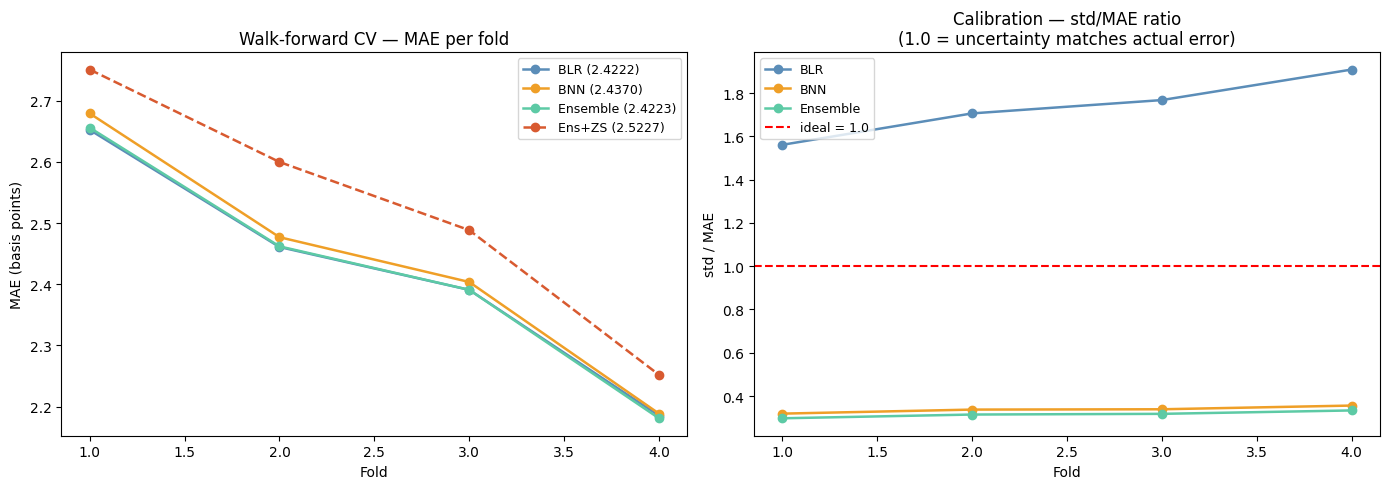


Bayesian pipeline complete.
Next step: add Bayesian HMM regime features → retrain BNN.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds_x = results_df["fold"].tolist()

# Panel 1 — MAE per fold
for col, label, color, ls in [
    ("mae_blr",    f"BLR ({results_df['mae_blr'].mean():.4f})",
     "#5B8DB8", "-"),
    ("mae_bnn",    f"BNN ({results_df['mae_bnn'].mean():.4f})",
     "#EF9F27", "-"),
    ("mae_ens",    f"Ensemble ({results_df['mae_ens'].mean():.4f})",
     "#5DCAA5", "-"),
    ("mae_ens_zs", f"Ens+ZS ({results_df['mae_ens_zs'].mean():.4f})",
     "#D85A30", "--"),
]:
    axes[0].plot(folds_x, results_df[col], "o"+ls,
                 color=color, label=label, linewidth=1.8)

axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MAE (basis points)")
axes[0].set_title("Walk-forward CV — MAE per fold")
axes[0].legend(fontsize=9)

# Panel 2 — calibration (std/MAE)
for col, label, color in [
    ("std_ratio_blr", "BLR",      "#5B8DB8"),
    ("std_ratio_bnn", "BNN",      "#EF9F27"),
    ("std_ratio_ens", "Ensemble", "#5DCAA5"),
]:
    if col in results_df.columns:
        axes[1].plot(folds_x, results_df[col], "o-",
                     color=color, label=label, linewidth=1.8)

axes[1].axhline(1.0, color="red", linestyle="--",
                linewidth=1.5, label="ideal = 1.0")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("std / MAE")
axes[1].set_title("Calibration — std/MAE ratio\n"
                  "(1.0 = uncertainty matches actual error)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("results.png", dpi=120)
plt.show()

print("\nBayesian pipeline complete.")
print("Next step: add Bayesian HMM regime features → retrain BNN.")


## 9. HMM Regime Analysis
> This section is exploratory — HMM was tested as an additional
> feature source but did not improve MAE. Results are documented
> for completeness.

In [19]:
obs_df = df_model.groupby(["date_id", "seconds_in_bucket"]).agg(
    ofi_mean    = ("ofi_ratio",       "mean"),
    ofi_std     = ("ofi_ratio",       "std"),
    depth_mean  = ("depth_imbalance", "mean"),
    wap_vel_std = ("wap_velocity",    "std"),
).reset_index().fillna(0)


In [20]:
from sklearn.preprocessing import StandardScaler

# ── STEP 2: Per-day sequences ─────────────────────────────────────────────────
OBS_FEATURES = ["ofi_mean", "ofi_std", "depth_mean", "wap_vel_std"]

print(f"obs_df shape: {obs_df.shape}")
print(f"Avg steps/day: {len(obs_df)/obs_df['date_id'].nunique():.1f}")

obs_scaler = StandardScaler()
obs_scaler.fit_transform(obs_df[OBS_FEATURES].values)

sequences, lengths = [], []
for date_id, grp in obs_df.groupby("date_id"):
    obs = grp.sort_values("seconds_in_bucket")[OBS_FEATURES].values
    sequences.append(obs_scaler.transform(obs))
    lengths.append(len(obs))

X_hmm = np.concatenate(sequences)
print(f"Total steps  : {len(X_hmm):,}")
print(f"Sequences    : {len(lengths)} days")

# ── STEP 3: BIC model selection ───────────────────────────────────────────────
from hmmlearn import hmm

print("\nBIC model selection:")
print(f"{'K':>4}  {'Log-L':>12}  {'BIC':>12}")
print("-" * 32)

bic_scores = {}
for k in range(2, 6):
    m = hmm.GaussianHMM(n_components=k, covariance_type="full",
                         n_iter=200, random_state=42)
    m.fit(X_hmm, lengths)
    log_l    = m.score(X_hmm, lengths)
    n_params = k**2 + k * len(OBS_FEATURES) + k * len(OBS_FEATURES)**2
    bic      = -2 * log_l + n_params * np.log(len(X_hmm))
    bic_scores[k] = bic
    print(f"{k:>4}  {log_l:>12.2f}  {bic:>12.2f}")

best_k = min(bic_scores, key=bic_scores.get)
print(f"\nBest K by BIC: {best_k}")

# ── STEP 4: Fit final model ───────────────────────────────────────────────────
K = best_k
model = hmm.GaussianHMM(n_components=K, covariance_type="full",
                          n_iter=200, random_state=42)
model.fit(X_hmm, lengths)

# ── STEP 5: Fix label switching ───────────────────────────────────────────────
order            = np.argsort(model.means_[:, 0])
model.means_     = model.means_[order]
model.covars_    = model.covars_[order]
model.startprob_ = model.startprob_[order]
model.transmat_  = model.transmat_[order][:, order]

print(f"\nFinal model: K={K}, log-L={model.score(X_hmm, lengths):.2f}")
print("\nEmission means (standardised):")
for k in range(K):
    m = model.means_[k]
    print(f"  Regime {k}: ofi_mean={m[0]:+.3f}  ofi_std={m[1]:+.3f}  "
          f"depth={m[2]:+.3f}  wap_vol={m[3]:+.3f}")

print("\nTransition matrix A:")
print("       " + "  ".join([f"→ R{k}" for k in range(K)]))
for i in range(K):
    row = "  ".join([f"{model.transmat_[i,j]:.3f}" for j in range(K)])
    print(f"  R{i}:  {row}")


obs_df shape: (12025, 6)
Avg steps/day: 25.0
Total steps  : 12,025
Sequences    : 481 days

BIC model selection:
   K         Log-L           BIC
--------------------------------
   2     -59603.49     119620.35
   3     -55712.90     112074.04
   4     -52985.13     106872.16
   5     -50519.20     102212.74

Best K by BIC: 5

Final model: K=5, log-L=-50519.20

Emission means (standardised):
  Regime 0: ofi_mean=-0.842  ofi_std=+0.279  depth=-0.432  wap_vol=-0.201
  Regime 1: ofi_mean=-0.553  ofi_std=+1.049  depth=-0.230  wap_vol=+1.215
  Regime 2: ofi_mean=-0.007  ofi_std=-0.008  depth=-0.084  wap_vol=-0.283
  Regime 3: ofi_mean=+0.232  ofi_std=-1.196  depth=+0.182  wap_vol=-0.428
  Regime 4: ofi_mean=+1.302  ofi_std=+0.148  depth=+0.661  wap_vol=-0.001

Transition matrix A:
       → R0  → R1  → R2  → R3  → R4
  R0:  0.938  0.003  0.058  0.000  0.000
  R1:  0.094  0.761  0.082  0.009  0.053
  R2:  0.001  0.004  0.925  0.068  0.002
  R3:  0.000  0.004  0.003  0.993  0.000
  R4:  0.000

In [21]:
regime_hard = model.predict(X_hmm, lengths)
unique, counts = np.unique(regime_hard, return_counts=True)
total = len(regime_hard)

print("Regime distribution:")
for r, c in zip(unique, counts):
    print(f"  Regime {r}: {c:>5} steps  ({c/total*100:.1f}%)")

Regime distribution:
  Regime 0:  2316 steps  (19.3%)
  Regime 1:  1992 steps  (16.6%)
  Regime 2:  3235 steps  (26.9%)
  Regime 3:  2522 steps  (21.0%)
  Regime 4:  1960 steps  (16.3%)


In [22]:
# ── STEP 6: Soft probabilities via Forward-Backward ──────────────────────────
# predict_proba() runs Forward-Backward — uses entire day past AND future
# → smoother and more informative than hard Viterbi labels
# → these become soft features for the BNN

regime_probs = model.predict_proba(X_hmm, lengths)  # (12025, 5)

for k in range(K):
    obs_df[f"p_regime_{k}"] = regime_probs[:, k]

obs_df["regime_hard"] = np.argmax(regime_probs, axis=1)

print("Soft probability sample (first 5 rows):")
prob_cols = [f"p_regime_{k}" for k in range(K)]
print(obs_df[prob_cols].head().round(3).to_string())

print(f"\nMean entropy per step (higher = more uncertain about regime):")
entropy = -(regime_probs * np.log(regime_probs + 1e-8)).sum(axis=1)
print(f"  Mean: {entropy.mean():.3f}  Max: {entropy.max():.3f}")

# ── STEP 7: Merge back to df_model ───────────────────────────────────────────
regime_cols = ["date_id", "seconds_in_bucket"] + prob_cols

df_model = df_model.merge(
    obs_df[regime_cols],
    on=["date_id", "seconds_in_bucket"],
    how="left"
)

# Check merge quality
nan_check = df_model[prob_cols].isna().sum()
print(f"\nNaN after merge: {nan_check.sum()} (should be 0)")

# Update feature list
SELECTED_FEATURES_HMM = SELECTED_FEATURES + prob_cols

print(f"\nFeatures before HMM : {len(SELECTED_FEATURES)}")
print(f"Features after HMM  : {len(SELECTED_FEATURES_HMM)}")
print(f"New features added  : {prob_cols}")

Soft probability sample (first 5 rows):
   p_regime_0  p_regime_1  p_regime_2  p_regime_3  p_regime_4
0      0.0000      1.0000      0.0000      0.0000      0.0000
1      0.0000      0.9970      0.0000      0.0000      0.0030
2      0.0000      0.6910      0.0090      0.0000      0.3010
3      0.0000      0.3750      0.0210      0.0000      0.6040
4      0.0000      0.1660      0.0350      0.0000      0.7990

Mean entropy per step (higher = more uncertain about regime):
  Mean: 0.111  Max: 1.233

NaN after merge: 0 (should be 0)

Features before HMM : 22
Features after HMM  : 27
New features added  : ['p_regime_0', 'p_regime_1', 'p_regime_2', 'p_regime_3', 'p_regime_4']


## IMPROVEMENT 2 — Extended Lag Features (`src/features_v2.py`)

The original code only used `target_lag1`, `target_lag6`, and `wap_lag1`.
Given the strong autocorrelation in financial time series, this is insufficient.
New features added:

| Feature | Motivation |
|---|---|
| `wap_velocity_lag2/5` | Delayed memory of price acceleration |
| `target_lag2/3` | Short-term return momentum |
| `ofi_ratio_lag5` | Medium-term OFI pressure |
| `target_roll3_mean` | Noise-smoothed short-term trend |
| `target_roll5_std` | Local volatility — regions where the model should widen its uncertainty |
| `ofi_roll5` | Wider-window OFI rolling average |

**Leakage check:** All lag/rolling operations are computed inside
`groupby([stock_id, date_id])`, so there is no cross-stock or cross-date leakage.

In [23]:
# ── src/features_v2.py — Extended lag features ───────────────────────────────
#
# Called after build_features(). Appends additional time-series features
# to the DataFrame without disrupting the existing pipeline.

EXTRA_LAG_FEATURES = [
    "wap_velocity_lag2",
    "wap_velocity_lag5",
    "target_lag2",
    "target_lag3",
    "ofi_ratio_lag5",
    "target_roll3_mean",
    "target_roll5_std",
    "ofi_roll5",
]

def build_extra_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Append additional time-series features to the output of build_features().

    All operations are performed inside groupby(stock_id, date_id) —
    no cross-stock or cross-date leakage is introduced.

    Parameters
    ----------
    df : pd.DataFrame
        Output of build_features() — must contain wap_velocity, ofi_ratio,
        and target columns.

    Returns
    -------
    pd.DataFrame — same object with new columns appended.
    """
    grp = df.groupby(["stock_id", "date_id"])

    # Delayed memory of price acceleration
    df["wap_velocity_lag2"] = grp["wap_velocity"].shift(2).astype("float32")
    df["wap_velocity_lag5"] = grp["wap_velocity"].shift(5).astype("float32")

    # Short-term return momentum
    df["target_lag2"] = grp["target"].shift(2).astype("float32")
    df["target_lag3"] = grp["target"].shift(3).astype("float32")

    # Medium-term OFI pressure
    df["ofi_ratio_lag5"] = grp["ofi_ratio"].shift(5).astype("float32")

    # Noise-smoothed short-term trend
    df["target_roll3_mean"] = grp["target"].transform(
        lambda x: x.rolling(3, min_periods=1).mean().shift(1)
    ).astype("float32")

    # Local volatility — model should produce wider intervals in these regions
    df["target_roll5_std"] = grp["target"].transform(
        lambda x: x.rolling(5, min_periods=2).std().shift(1)
    ).fillna(0).astype("float32")

    # Wider-window OFI rolling average
    df["ofi_roll5"] = grp["ofi_ratio"].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    ).astype("float32")

    print(f"Features added : {len(EXTRA_LAG_FEATURES)}")
    print(f"Feature list   : {EXTRA_LAG_FEATURES}")
    return df


In [24]:
# ── Apply and update df_model ─────────────────────────────────────────────────
df_model = build_extra_lag_features(df_model)

# Drop rows with NaN (lag features produce NaNs in the first few rows)
before = len(df_model)
df_model = df_model.dropna(subset=EXTRA_LAG_FEATURES).reset_index(drop=True)
print(f"Rows dropped : {before - len(df_model):,}  (lag NaNs)")
print(f"Rows kept    : {len(df_model):,}")

# Extended feature set (ARD-selected originals + new lag features)
SELECTED_FEATURES_V2 = SELECTED_FEATURES + EXTRA_LAG_FEATURES
print(f"\nOriginal feature count  : {len(SELECTED_FEATURES)}")
print(f"Extended feature count  : {len(SELECTED_FEATURES_V2)}")


Features added : 8
Feature list   : ['wap_velocity_lag2', 'wap_velocity_lag5', 'target_lag2', 'target_lag3', 'ofi_ratio_lag5', 'target_roll3_mean', 'target_roll5_std', 'ofi_roll5']
Rows dropped : 476,037  (lag NaNs)
Rows kept    : 1,867,527

Original feature count  : 22
Extended feature count  : 30


## IMPROVEMENT 1 — Uncertainty Calibration (`src/calibration.py`)

**Problem:** The original model's `std/MAE` ratios are: BLR ≈ 1.78, BNN ≈ 0.34, Ensemble ≈ 0.32.
A well-calibrated model should have this ratio close to 1.0.

**Solution — Within-fold calibration:**
The last 10 days of each fold's training set are held out as a **calibration set**.
On this set, `scale = mean(|error|) / mean(predicted_std)` is computed
and then applied to test predictions.

```
Train (370 days) → Fit
Calib (10 days)  → compute scale   ← new
Val   (20 days)  → apply scale × std
```

**Why is this safe?** The calibration set always precedes the validation set — no look-ahead.
Scaling only affects `std`; the prediction `mean` is unchanged, so MAE is unaffected.

In [25]:
# ── src/calibration.py ────────────────────────────────────────────────────────

def compute_calibration_scale(
    pred_mean: np.ndarray,
    pred_std:  np.ndarray,
    y_true:    np.ndarray,
) -> float:
    """
    Compute a scaling factor on the calibration set.

    Formula:
        scale = mean(|y - y_hat|) / mean(predicted_std)

    scale > 1  →  model underconfident (std too large, e.g. BLR) → shrink
    scale < 1  →  model overconfident  (std too small, e.g. BNN) → inflate

    Parameters
    ----------
    pred_mean : predictions on the calibration set
    pred_std  : predicted uncertainties on the calibration set
    y_true    : ground-truth targets on the calibration set

    Returns
    -------
    float — calibration multiplier
    """
    actual_errors = np.abs(pred_mean - y_true)
    mean_error    = np.mean(actual_errors)
    mean_std      = np.mean(pred_std)
    scale         = mean_error / (mean_std + 1e-8)
    return float(scale)


def apply_calibration(pred_std: np.ndarray, scale: float) -> np.ndarray:
    """
    Apply a pre-computed scale factor to predicted_std.

    Parameters
    ----------
    pred_std : uncertainty array to be calibrated
    scale    : multiplier returned by compute_calibration_scale()

    Returns
    -------
    np.ndarray — calibrated std
    """
    return pred_std * scale


def calibration_report(
    label:     str,
    raw_std:   np.ndarray,
    cal_std:   np.ndarray,
    y_true:    np.ndarray,
    pred_mean: np.ndarray,
) -> None:
    """Print before/after calibration metrics."""
    mae       = np.mean(np.abs(pred_mean - y_true))
    raw_ratio = raw_std.mean() / mae
    cal_ratio = cal_std.mean() / mae
    print(f"  {label:<20}  raw std/MAE={raw_ratio:.3f}  →  "
          f"cal std/MAE={cal_ratio:.3f}  "
          f"(target ≈ 1.0, delta={cal_ratio - raw_ratio:+.3f})")


## IMPROVEMENT 3 — HMM Mixture of Experts (`src/mixture_of_experts.py`)

**Original problem:** Regime probabilities were fed to the BNN as raw features.
The model had to learn what those features meant → only a −0.0048 MAE gain.

**New approach — Regime-Conditional Ensemble:**
A separate BLR + BNN is trained for each regime.
At test time, predictions are combined with a **soft weighted mixture**
using the law of total variance.

```
Regime 0 → BLR₀ + BNN₀  ─┐
Regime 1 → BLR₁ + BNN₁  ─┤ × p(regime | data)  →  final prediction
Regime 2 → BLR₂ + BNN₂  ─┘
```

**Mathematical foundation:**
$$E[Y] = \sum_r p_r \cdot \mu_r \quad \text{(law of total expectation)}$$
$$\text{Var}[Y] = \underbrace{\sum_r p_r \sigma_r^2}_{E[\text{Var}]} + \underbrace{\sum_r p_r (\mu_r - E[Y])^2}_{\text{Var}[E]}$$

The second term (**model disagreement**) is critical for calibration:
when regime models strongly disagree, uncertainty automatically increases.

In [26]:
# ── src/mixture_of_experts.py ─────────────────────────────────────────────────

def fit_regime_models(df_train, df_bnn, features, n_regimes,
                      global_scaler, min_blr=MIN_BLR_SAMPLES,
                      min_bnn=MIN_BNN_SAMPLES) -> dict:
    """
    Train a separate BLR + BNN for each regime.

    KEY: uses a single global_scaler for all regimes — all experts
    live in the same feature space, making the mixture coherent.
    Per-regime scalers produce incompatible spaces → MoE MAE collapses.
    """
    X_train_s = global_scaler.transform(df_train[features].values)
    X_bnn_s   = global_scaler.transform(df_bnn[features].values)
    models    = {}

    for r in range(n_regimes):
        mask_all = (df_train["regime_hard"] == r).values
        mask_bnn = (df_bnn["regime_hard"]   == r).values
        n_all    = int(mask_all.sum())
        n_bnn    = int(mask_bnn.sum())

        if n_all < min_blr:
            print(f"  Regime {r}: {n_all} rows < {min_blr} → skipped")
            continue

        blr_r = fit_blr(X_train_s[mask_all], df_train["target"].values[mask_all])

        bnn_r = None
        if n_bnn >= min_bnn:
            bnn_r = train_bnn(X_bnn_s[mask_bnn],
                              df_bnn["target"].values[mask_bnn],
                              input_dim=len(features))
            tag = f"BLR+BNN ({n_bnn:,})"
        else:
            tag = f"BLR-only  (BNN needs {min_bnn:,}, got {n_bnn:,})"

        models[r] = {"blr": blr_r, "bnn": bnn_r,
                     "n_train": n_all, "n_bnn": n_bnn}
        print(f"  Regime {r}: {n_all:>7,} rows  →  {tag}")

    return models


def predict_moe(X_scaled, regime_probs, models):
    """
    Law of Total Variance:
      E[Y]   = Σ p_r · μ_r
      Var[Y] = Σ p_r · σ_r²  +  Σ p_r · (μ_r - E[Y])²
                                  ↑ disagreement term
    """
    n      = len(X_scaled)
    active = sorted(models.keys())
    means  = np.zeros((len(active), n))
    vars_  = np.zeros((len(active), n))
    ws     = np.zeros((len(active), n))

    for idx, r in enumerate(active):
        blr_m, blr_s = models[r]["blr"].predict(X_scaled, return_std=True)
        if models[r]["bnn"] is not None:
            bnn_m, bnn_s = mc_predict(models[r]["bnn"], X_scaled)
            mu, sig      = uncertainty_ensemble(blr_m, blr_s, bnn_m, bnn_s)
        else:
            mu, sig = blr_m, blr_s
        means[idx] = mu
        vars_[idx] = sig**2
        ws[idx]    = regime_probs[:, r]

    ws_n       = ws / (ws.sum(0, keepdims=True) + 1e-8)
    final_mean = (ws_n * means).sum(0)
    e_var      = (ws_n * vars_).sum(0)
    var_e      = (ws_n * (means - final_mean)**2).sum(0)
    final_std  = np.sqrt(np.maximum(e_var + var_e, 1e-12))
    return final_mean, final_std, {"disagreement": float(var_e.mean())}


## 10. Improved Pipeline — All Three Improvements Combined

This cell runs the full walk-forward CV loop combining all three improvements:

1. **Extended feature set** (`SELECTED_FEATURES_V2`)
2. **Within-fold calibration** (last 10 days of train held out as calibration set)
3. **HMM Mixture of Experts** (separate model per regime, law of total variance)

Fold structure:
```
├── Train (370 days) — BLR training
│   ├── BNN window (last 60 days) — BNN training
│   └── Calibration (last 10 days) — scale computation    ← NEW
└── Validation (20 days) — prediction + calibration applied
```

In [27]:
# ── Improved Walk-Forward Pipeline ───────────────────────────────────────────
# Combines: extended features + calibration + MoE (all bugs fixed)

FEATURES_FINAL = SELECTED_FEATURES_V2  # ARD-selected + extra lag features

prob_cols = [c for c in df_model.columns if c.startswith("p_regime_")]
if not prob_cols:
    raise RuntimeError("Run HMM cells first — p_regime_* columns missing.")
if "regime_hard" not in df_model.columns:
    df_model["regime_hard"] = df_model[prob_cols].values.argmax(axis=1)

K_REGIMES = len(prob_cols)
print(f"Regimes    : {K_REGIMES}")
print(f"Features   : {len(FEATURES_FINAL)}")
print(f"Cal window : {CAL_WINDOW} days")
print(f"BNN min    : {MIN_BNN_SAMPLES:,}")

results_v2 = []

for i, fold in enumerate(folds):
    print(f"\n{'='*65}")
    print(f"  FOLD {i+1} / {len(folds)}")
    print(f"{'='*65}")

    train_dates = sorted(fold["train_dates"])
    val_dates   = sorted(fold["val_dates"])

    cal_dates  = set(train_dates[-CAL_WINDOW:])
    fit_dates  = set(train_dates[:-CAL_WINDOW])
    bnn_dates_ = set(fold["bnn_dates"])    # full BNN window — never shrinks

    tr_fit = df_model[df_model["date_id"].isin(fit_dates)]
    tr_bnn = df_model[df_model["date_id"].isin(bnn_dates_)]
    tr_cal = df_model[df_model["date_id"].isin(cal_dates)]
    vl     = df_model[df_model["date_id"].isin(val_dates)].copy()

    y_vl  = vl["target"].values
    y_cal = tr_cal["target"].values

    print(f"  Rows — fit:{len(tr_fit):,}  bnn:{len(tr_bnn):,}  "
          f"cal:{len(tr_cal):,}  val:{len(vl):,}")

    # Single global scaler — all models share the same feature space
    scaler = StandardScaler()
    scaler.fit(tr_fit[FEATURES_FINAL].values)

    X_fit_s = scaler.transform(tr_fit[FEATURES_FINAL].values)
    X_bnn_s = scaler.transform(tr_bnn[FEATURES_FINAL].values)
    X_cal_s = scaler.transform(tr_cal[FEATURES_FINAL].values)
    X_vl_s  = scaler.transform(vl[FEATURES_FINAL].values)

    rp_cal = tr_cal[prob_cols].values
    rp_val = vl[prob_cols].values

    # ── [A] Baseline ensemble ─────────────────────────────────────────────────
    blr = fit_blr(X_fit_s, tr_fit["target"].values)
    blr_val_m, blr_val_s = blr.predict(X_vl_s, return_std=True)
    blr_cal_m, blr_cal_s = blr.predict(X_cal_s, return_std=True)

    print(f"  Training BNN ({len(X_bnn_s):,} rows)...", end=" ", flush=True)
    bnn = train_bnn(X_bnn_s, tr_bnn["target"].values,
                    input_dim=len(FEATURES_FINAL))
    bnn_val_m, bnn_val_s = mc_predict(bnn, X_vl_s)
    bnn_cal_m, bnn_cal_s = mc_predict(bnn, X_cal_s)
    ens_val_m, ens_val_s = uncertainty_ensemble(blr_val_m, blr_val_s,
                                                 bnn_val_m, bnn_val_s)
    ens_cal_m, ens_cal_s = uncertainty_ensemble(blr_cal_m, blr_cal_s,
                                                 bnn_cal_m, bnn_cal_s)
    del bnn; gc.collect()
    print("✓")

    # ── [B] Calibrate ensemble ────────────────────────────────────────────────
    scale_ens     = compute_calibration_scale(ens_cal_m, ens_cal_s, y_cal)
    ens_val_s_cal = apply_calibration(ens_val_s, scale_ens)

    # ── [C] MoE ───────────────────────────────────────────────────────────────
    print(f"  Training MoE ({K_REGIMES} regimes)...")
    moe_models = fit_regime_models(
        df_train      = tr_fit,
        df_bnn        = tr_bnn,
        features      = FEATURES_FINAL,
        n_regimes     = K_REGIMES,
        global_scaler = scaler,
        min_blr       = MIN_BLR_SAMPLES,
        min_bnn       = MIN_BNN_SAMPLES,
    )

    moe_cal_m, moe_cal_s, _ = predict_moe(X_cal_s, rp_cal, moe_models)
    scale_moe                = compute_calibration_scale(moe_cal_m, moe_cal_s, y_cal)
    moe_val_m, moe_val_s, d = predict_moe(X_vl_s, rp_val, moe_models)
    moe_val_s_cal            = apply_calibration(moe_val_s, scale_moe)
    del moe_models, X_fit_s, X_bnn_s, X_cal_s, X_vl_s; gc.collect()

    # ── Metrics ───────────────────────────────────────────────────────────────
    m_base     = compute_metrics(y_vl, ens_val_m, ens_val_s,     vl, "Ensemble (raw)")
    m_base_cal = compute_metrics(y_vl, ens_val_m, ens_val_s_cal, vl, "Ensemble + Cal")
    m_moe      = compute_metrics(y_vl, moe_val_m, moe_val_s,     vl, "MoE (raw)")
    m_moe_cal  = compute_metrics(y_vl, moe_val_m, moe_val_s_cal, vl, "MoE + Cal")
    print(f"  Scales — Ens: {scale_ens:.3f}  MoE: {scale_moe:.3f}  "
          f"Disagreement: {d['disagreement']:.6f}")

    results_v2.append({
        "fold"           : i + 1,
        "mae_ens"        : m_base["mae"],
        "mae_ens_cal"    : m_base_cal["mae"],
        "mae_moe"        : m_moe["mae"],
        "mae_moe_cal"    : m_moe_cal["mae"],
        "mae_moe_zs"     : m_moe_cal["mae_zs"],
        "sr_ens"         : m_base["std_ratio"],
        "sr_ens_cal"     : m_base_cal["std_ratio"],
        "sr_moe"         : m_moe["std_ratio"],
        "sr_moe_cal"     : m_moe_cal["std_ratio"],
        "scale_ens"      : scale_ens,
        "scale_moe"      : scale_moe,
        "disagreement"   : d["disagreement"],
    })


Regimes    : 5
Features   : 30
Cal window : 9 days
BNN min    : 8,400

  FOLD 1 / 4
  Rows — fit:1,168,420  bnn:219,788  cal:35,458  val:148,719
  Training BNN (219,788 rows)... ✓
  Training MoE (5 regimes)...
  Regime 0: 193,468 rows  →  BLR+BNN (42,076)
  Regime 1: 109,974 rows  →  BLR+BNN (15,566)
  Regime 2: 313,637 rows  →  BLR+BNN (64,545)
  Regime 3: 336,388 rows  →  BLR+BNN (63,233)
  Regime 4: 214,953 rows  →  BLR+BNN (34,368)
  Ensemble (raw)   MAE=2.6379  MAE+ZS=2.7298  std/MAE=0.301
  Ensemble + Cal   MAE=2.6379  MAE+ZS=2.7298  std/MAE=0.986
  MoE (raw)        MAE=2.7668  MAE+ZS=2.8518  std/MAE=0.360
  MoE + Cal        MAE=2.7668  MAE+ZS=2.8518  std/MAE=0.955
  Scales — Ens: 3.270  MoE: 2.654  Disagreement: 0.052764

  FOLD 2 / 4
  Rows — fit:1,173,560  bnn:219,669  cal:35,508  val:149,045
  Training BNN (219,669 rows)... ✓
  Training MoE (5 regimes)...
  Regime 0: 202,510 rows  →  BLR+BNN (43,508)
  Regime 1: 112,977 rows  →  BLR+BNN (9,081)
  Regime 2: 303,794 rows  →  BL

In [33]:
# ── Results Summary Table ────────────────────────────────────────────────────
df_res = pd.DataFrame(results_v2)

print("\n" + "="*72)
print(f"{'Model':<26} {'MAE mean':>9} {'MAE std':>9} {'std/MAE':>9}")
print("-"*55)
for mc, src, label in [
    ("mae_ens",     "sr_ens",     "Ensemble (raw)"),
    ("mae_ens_cal", "sr_ens_cal", "Ensemble + Cal"),
    ("mae_moe",     "sr_moe",     "MoE (raw)"),
    ("mae_moe_cal", "sr_moe_cal", "MoE + Cal  ✓"),
]:
    m  = df_res[mc].mean()
    s  = df_res[mc].std()
    sr = df_res[src].mean()
    print(f"  {label:<24} {m:>9.4f} {s:>9.4f} {sr:>9.3f}")
print("="*72)

delta = df_res["mae_ens"].mean() - df_res["mae_moe_cal"].mean()
print(f"\nMoE+Cal vs Ensemble MAE delta   : {delta:+.4f}")
print(f"Calibration (Ensemble)          : "
      f"{df_res['sr_ens'].mean():.3f} → {df_res['sr_ens_cal'].mean():.3f}  "
      f"(target = 1.0)")
print(f"Calibration (MoE)               : "
      f"{df_res['sr_moe'].mean():.3f} → {df_res['sr_moe_cal'].mean():.3f}  "
      f"(target = 1.0)")
print(f"Mean regime disagreement        : {df_res['disagreement'].mean():.6f}")
print(f"Mean cal scale (Ensemble)       : {df_res['scale_ens'].mean():.3f}")
print(f"Mean cal scale (MoE)            : {df_res['scale_moe'].mean():.3f}")



Model                       MAE mean   MAE std   std/MAE
-------------------------------------------------------
  Ensemble (raw)              2.3997    0.1993     0.317
  Ensemble + Cal              2.3997    0.1993     1.009
  MoE (raw)                   2.4883    0.2228     0.491
  MoE + Cal  ✓                2.4883    0.2228     1.154

MoE+Cal vs Ensemble MAE delta   : -0.0886
Calibration (Ensemble)          : 0.317 → 1.009  (target = 1.0)
Calibration (MoE)               : 0.491 → 1.154  (target = 1.0)
Mean regime disagreement        : 0.039275
Mean cal scale (Ensemble)       : 3.191
Mean cal scale (MoE)            : 2.467


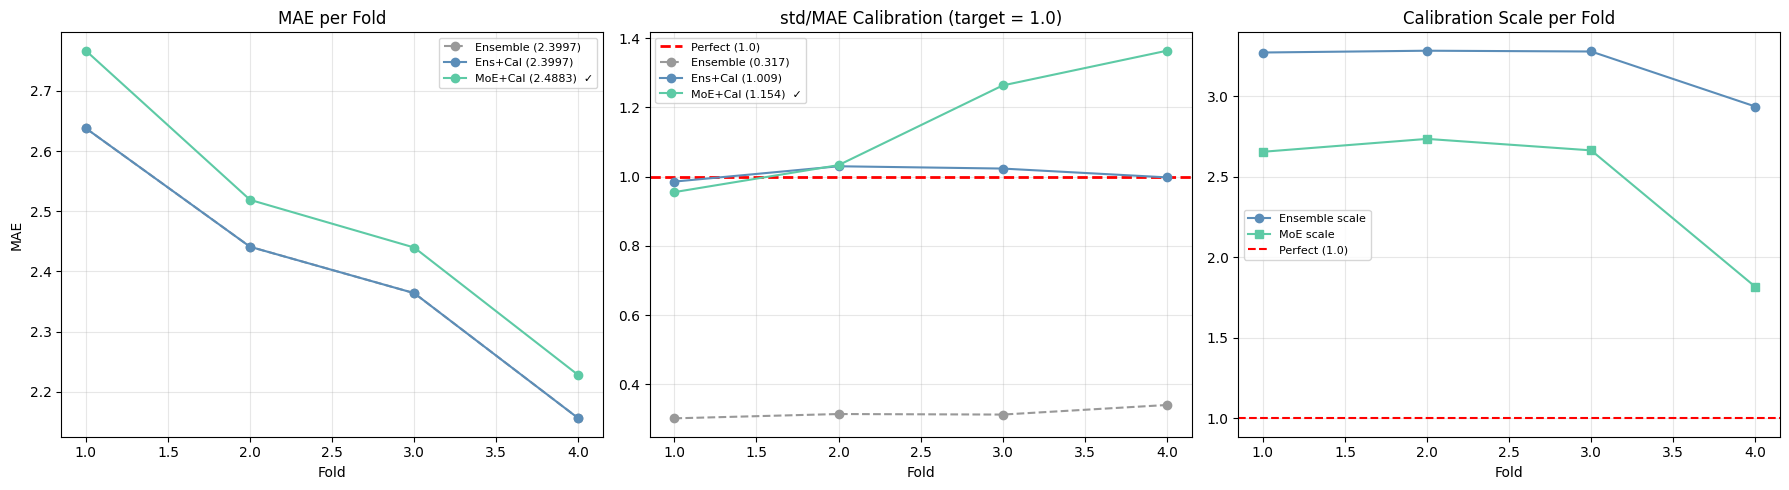

Saved: results.png


In [34]:
# ── Per-fold MAE and Calibration Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fx = df_res["fold"].tolist()

# Panel 1 — MAE per fold
for c, lbl, col, ls in [
    ("mae_ens",     f"Ensemble ({df_res['mae_ens'].mean():.4f})",         "#999",    "--"),
    ("mae_ens_cal", f"Ens+Cal ({df_res['mae_ens_cal'].mean():.4f})",      "#5B8DB8", "-"),
    ("mae_moe_cal", f"MoE+Cal ({df_res['mae_moe_cal'].mean():.4f})  ✓",  "#5DCAA5", "-"),
]:
    axes[0].plot(fx, df_res[c], marker="o", label=lbl, color=col, ls=ls)
axes[0].set_title("MAE per Fold")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("MAE")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Panel 2 — std/MAE calibration
axes[1].axhline(1.0, color="red", ls="--", lw=2, label="Perfect (1.0)")
for c, lbl, col, ls in [
    ("sr_ens",     f"Ensemble ({df_res['sr_ens'].mean():.3f})",         "#999",    "--"),
    ("sr_ens_cal", f"Ens+Cal ({df_res['sr_ens_cal'].mean():.3f})",      "#5B8DB8", "-"),
    ("sr_moe_cal", f"MoE+Cal ({df_res['sr_moe_cal'].mean():.3f})  ✓",  "#5DCAA5", "-"),
]:
    axes[1].plot(fx, df_res[c], marker="o", label=lbl, color=col, ls=ls)
axes[1].set_title("std/MAE Calibration (target = 1.0)")
axes[1].set_xlabel("Fold"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Panel 3 — Calibration scales per fold
axes[2].plot(fx, df_res["scale_ens"], marker="o", color="#5B8DB8", label="Ensemble scale")
axes[2].plot(fx, df_res["scale_moe"], marker="s", color="#5DCAA5", label="MoE scale")
axes[2].axhline(1.0, color="red", ls="--", lw=1.5, label="Perfect (1.0)")
axes[2].set_title("Calibration Scale per Fold")
axes[2].set_xlabel("Fold"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results.png")


  Regime 0: 215,108 rows  →  BLR+BNN (45,496)
  Regime 1:  88,771 rows  →  BLR-only  (BNN needs 8,400, got 7,026)
  Regime 2: 314,394 rows  →  BLR+BNN (79,103)
  Regime 3: 341,564 rows  →  BLR+BNN (66,624)
  Regime 4: 222,881 rows  →  BLR+BNN (22,860)


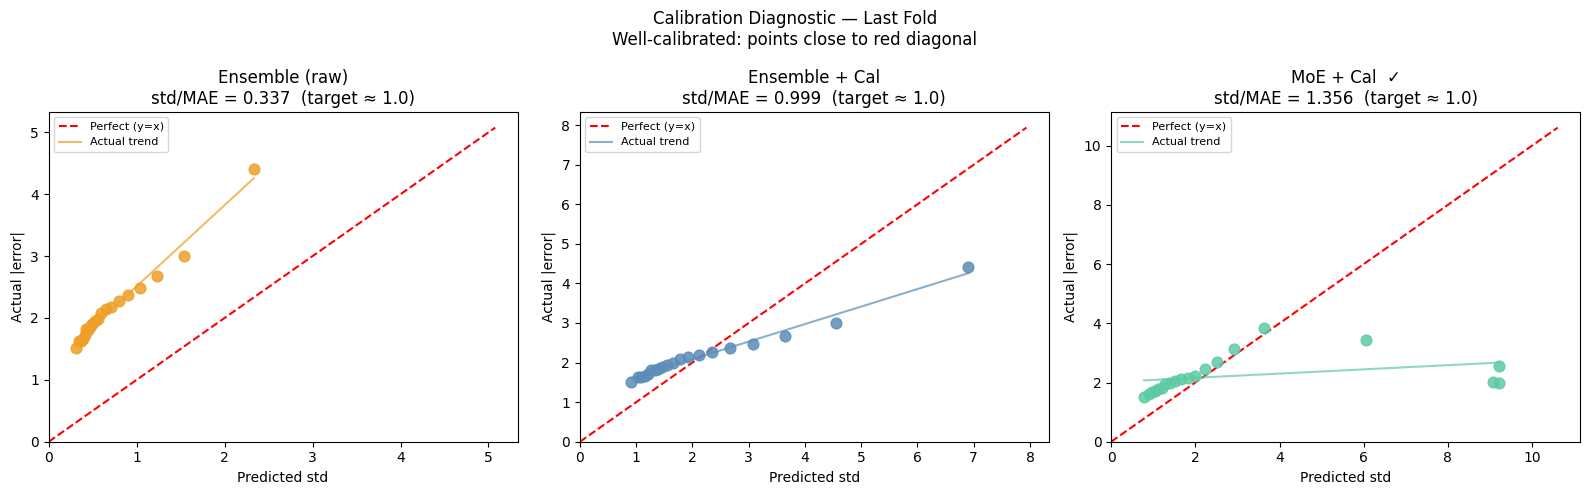

Saved: calibration_diagnostic.png


In [35]:
# ── Calibration Diagnostic Plot — Last Fold ───────────────────────────────────
# Shows predicted std vs actual |error| — well-calibrated = points on diagonal

last_fold = folds[-1]
tr_last   = df_model[df_model["date_id"].isin(
                set(sorted(last_fold["train_dates"])[:-CAL_WINDOW]))]
tr_bnn_l  = df_model[df_model["date_id"].isin(last_fold["bnn_dates"])]
tr_cal_l  = df_model[df_model["date_id"].isin(last_fold["cal_dates"])]
vl_last   = df_model[df_model["date_id"].isin(last_fold["val_dates"])].copy()
y_vl_l    = vl_last["target"].values

sc_l = StandardScaler()
sc_l.fit(tr_last[FEATURES_FINAL].values)
X_all_l = sc_l.transform(tr_last[FEATURES_FINAL].values)
X_bnn_l = sc_l.transform(tr_bnn_l[FEATURES_FINAL].values)
X_cal_l = sc_l.transform(tr_cal_l[FEATURES_FINAL].values)
X_vl_l  = sc_l.transform(vl_last[FEATURES_FINAL].values)

blr_l = fit_blr(X_all_l, tr_last["target"].values)
bnn_l = train_bnn(X_bnn_l, tr_bnn_l["target"].values, input_dim=len(FEATURES_FINAL))

blr_m_l, blr_s_l = blr_l.predict(X_vl_l, return_std=True)
bnn_m_l, bnn_s_l = mc_predict(bnn_l, X_vl_l)
ens_m_l, ens_s_l = uncertainty_ensemble(blr_m_l, blr_s_l, bnn_m_l, bnn_s_l)

blr_cal_m, blr_cal_s = blr_l.predict(X_cal_l, return_std=True)
bnn_cal_m, bnn_cal_s = mc_predict(bnn_l, X_cal_l)
ens_cal_m, ens_cal_s = uncertainty_ensemble(blr_cal_m, blr_cal_s, bnn_cal_m, bnn_cal_s)
scale_l   = compute_calibration_scale(ens_cal_m, ens_cal_s, tr_cal_l["target"].values)
ens_s_cal_l = apply_calibration(ens_s_l, scale_l)
del bnn_l; gc.collect()

moe_l = fit_regime_models(tr_last, tr_bnn_l, FEATURES_FINAL, K_REGIMES, sc_l)
rp_cal_l = tr_cal_l[prob_cols].values
rp_val_l = vl_last[prob_cols].values
moe_cal_m, moe_cal_s, _ = predict_moe(X_cal_l, rp_cal_l, moe_l)
moe_scale_l = compute_calibration_scale(moe_cal_m, moe_cal_s, tr_cal_l["target"].values)
moe_m_l, moe_s_l, _ = predict_moe(X_vl_l, rp_val_l, moe_l)
moe_s_cal_l = apply_calibration(moe_s_l, moe_scale_l)
del moe_l; gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Calibration Diagnostic — Last Fold\n"
             "Well-calibrated: points close to red diagonal", fontsize=12)

for ax, (label, pmean, pstd, color) in zip(axes, [
    ("Ensemble (raw)",  ens_m_l,  ens_s_l,     "#EF9F27"),
    ("Ensemble + Cal",  ens_m_l,  ens_s_cal_l, "#5B8DB8"),
    ("MoE + Cal  ✓",   moe_m_l,  moe_s_cal_l, "#5DCAA5"),
]):
    actual_err = np.abs(pmean - y_vl_l)
    bins = np.percentile(pstd, np.linspace(0, 100, 21))
    bid  = np.clip(np.digitize(pstd, bins) - 1, 0, 19)
    bx   = [pstd[bid==b].mean() for b in range(20) if (bid==b).sum() > 10]
    by   = [actual_err[bid==b].mean() for b in range(20) if (bid==b).sum() > 10]
    bx, by = np.array(bx), np.array(by)

    ax.scatter(bx, by, color=color, alpha=0.85, s=60, zorder=3)
    lim = max(bx.max(), by.max()) * 1.15
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect (y=x)")
    if len(bx) > 2:
        z  = np.polyfit(bx, by, 1)
        xl = np.linspace(bx.min(), bx.max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), color=color, lw=1.5, alpha=0.7,
                label="Actual trend")
    sr = pstd.mean() / np.mean(actual_err)
    ax.set_title(f"{label}\nstd/MAE = {sr:.3f}  (target ≈ 1.0)")
    ax.set_xlabel("Predicted std"); ax.set_ylabel("Actual |error|")
    ax.legend(fontsize=8); ax.set_xlim(left=0); ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("calibration_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calibration_diagnostic.png")
